# moe-fmnist-mixture-of-experts-pytorch

Mixture-of-Experts (MoE) classifier on Fashion-MNIST via `nnx.MoELinear` + `nnx.moe_train_step_factory`. Demonstrates sparse expert routing (top-k=2 of 4 experts per token) and the Switch-style load-balancing auxiliary loss that keeps the router from collapsing onto a single expert.


# 1. Overview

## 1.1 Task & motivation

A Mixture-of-Experts (MoE) layer replaces a single `nn.Linear` with `num_experts` parallel linears + a learned router that picks `top_k` of them per token. Per-token FLOPs stay roughly constant (only `top_k` of `num_experts` actually run), but the parameter budget grows linearly with `num_experts`. The MoE bet: different experts can *specialize* on different input subdistributions, so total capacity goes up without proportional inference cost.

The hard part is **load balancing**. Without an auxiliary penalty, the router tends to collapse onto one or two experts and the rest of the budget goes to waste. `nnx.moe_train_step_factory(aux_loss_weight=...)` augments the standard supervised step with the Switch-Transformer-style aux loss summed across every `MoELinear` layer.

## 1.2 Dataset summary

Fashion-MNIST (10 apparel classes, 28×28 grayscale) via `nnx.NNDataset`. Same shape as MNIST so the recipe drops in unchanged.

## 1.3 Approach in one paragraph

Build a small `FeedFwdNN` subclass (`MoEClassifier`) that swaps its first hidden Linear for `MoELinear(in_features=784, out_features=128, num_experts=4, top_k=2)`. Train for 2 epochs with `moe_train_step_factory(aux_loss_weight=0.05)`. Track the per-batch aux loss (which lives on `moe_layer.last_aux_loss`) and verify it decreases — proof that load balancing is working. Render the final routing distribution (fraction of tokens routed to each expert).

## 1.4 Libraries used

`nnx` (`MoELinear`, `moe_train_step_factory`, `NNModel`, `NNDataset`, `FeedFwdNN`, `set_seed`), `torch`, `torchvision`, `matplotlib`, `prettytable`.


# 2. Environment & Setup

## 2.1 Imports

In [1]:
SMOKE_TEST = 0
SMOKE_TEST_EPOCHS = 1


In [2]:
import matplotlib.pyplot as plt
import torch
import torchvision as thv
from prettytable import PrettyTable
from torch.utils.data import DataLoader

import nnx
from nnx import (
    Activations,
    Devices,
    Losses,
    MoELinear,
    Nets,
    NNModel,
    NNModelParams,
    NNOptimParams,
    NNParams,
    NNTrainParams,
    Optims,
    moe_train_step_factory,
)
from nnx.nn.dataset.nn_dataset import NNDataset
from nnx.nn.net.feed_fwd_nn import FeedFwdNN


## 2.2 Configuration / hyperparameters

In [3]:
DS_MEAN: float = 0.1307
DS_STD: float = 0.3081
HIDDEN_DIMS = [128]
NUM_EXPERTS = 4
TOP_K = 2
AUX_LOSS_WEIGHT = 0.05
N_EPOCHS = SMOKE_TEST_EPOCHS if SMOKE_TEST else 2
BATCH_SIZE = 128
LR = 1e-3


## 2.3 Reproducibility (seed, device)

In [4]:
nnx.set_seed(0)
DEVICE = Devices.CPU


# 3. Data

## 3.1 Loading

In [5]:
ds = NNDataset(
    ds_class=thv.datasets.FashionMNIST,
    transform=thv.transforms.Compose([
        thv.transforms.ToTensor(),
        thv.transforms.Normalize(mean=DS_MEAN, std=DS_STD),
    ]),
)
# Rebuild the train loader at a per-batch granularity — NNDataset's default
# packs the whole train set into one batch.
train_loader = DataLoader(ds.train_loader.dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f"input_dim={ds.input_dim}, batches/epoch: {len(train_loader)}")


input_dim=784, batches/epoch: 422


## 3.2 Inspection / EDA

Fashion-MNIST has 10 classes (t-shirt, trousers, pullover, dress, coat, sandal, shirt, sneaker, bag, ankle-boot). Same `28x28` grayscale + 10-way classification as MNIST so the architectural recipe transfers.

## 3.3 Preprocessing & splits

`NNDataset` provides the standard torchvision train/val split. MNIST normalization stats reused for simplicity.


# 4. Model

## 4.1 MoEClassifier — subclass FeedFwdNN, swap first hidden for MoELinear


In [6]:
class MoEClassifier(FeedFwdNN):
    """FeedFwdNN whose first hidden layer is an MoELinear.

    Subclassing FeedFwdNN inherits the (X,), Y = unpack_batch contract
    so the model still trains via NNModel.train(train_step_fn=...) with
    no further plumbing. Adapted from nnx/examples/14_moe_classifier.py.
    """
    def __init__(self, params, *, num_experts, top_k):
        super().__init__(params)
        in_dim = params.dims[0]
        out_dim = params.dims[1]
        self.layers[0] = MoELinear(in_dim, out_dim,
                                    num_experts=num_experts, top_k=top_k)


## 4.2 NNModel + MoEClassifier construction

Build the shell with a placeholder `FeedFwdNN`, then swap `model.net` for the `MoEClassifier`. Same trick used by the diffusion + autoencoder tasks for `.net` substitution.


In [7]:
net_params = NNParams(
    input_dim=ds.input_dim,
    output_dim=ds.output_dim,
    hidden_dims=HIDDEN_DIMS,
    dropout_prob=0.0,
    activation=Activations.RELU,
)
model = NNModel(
    net_params=net_params,
    params=NNModelParams(net=Nets.FEED_FWD, device=DEVICE, loss=Losses.CROSS_ENTROPY),
)
model.net = MoEClassifier(net_params, num_experts=NUM_EXPERTS, top_k=TOP_K).to(model.device)

moe_layer = model.net.layers[0]
total = sum(p.numel() for p in model.net.parameters())
expert_p = sum(p.numel() for e in moe_layer.experts for p in e.parameters())
router_p = sum(p.numel() for p in moe_layer.router.parameters())
classifier_p = total - expert_p - router_p

t = PrettyTable()
t.title = f"MoE classifier: {NUM_EXPERTS} experts, top_k={TOP_K}"
t.field_names = ["component", "params"]
t.add_row(["router",          f"{router_p:,}"])
t.add_row([f"experts (×{NUM_EXPERTS})", f"{expert_p:,}"])
t.add_row(["classifier head", f"{classifier_p:,}"])
t.add_row(["TOTAL",            f"{total:,}"])
print(t)


+------------------------------------+
| MoE classifier: 4 experts, top_k=2 |
+-----------------------+------------+
|       component       |   params   |
+-----------------------+------------+
|         router        |   3,136    |
|      experts (×4)     |  401,920   |
|    classifier head    |   1,290    |
|         TOTAL         |  406,346   |
+-----------------------+------------+


## 4.3 Contracts

- `MoELinear(in, out, num_experts, top_k)` is a drop-in replacement for `nn.Linear(in, out)`. The router is a single `Linear(in, num_experts)`; the experts are `num_experts` independent `Linear(in, out)`. Each forward routes each token to its top-k experts and sums their outputs weighted by router softmax probabilities.
- `moe_train_step_factory(aux_loss_weight=0.05)` returns a `train_step_fn` that computes standard supervised CE + `aux_loss_weight * sum(last_aux_loss for each MoELinear)`. The aux loss is the Switch-Transformer load-balancing penalty — it's 1.0 at uniform routing and larger when the router collapses.


# 5. Training

## 5.1 Pre-training aux-loss snapshot

In [8]:
# Probe the aux loss BEFORE training so we have a baseline to compare against.
model.net.eval()
all_X = []
for X, _ in train_loader:
    all_X.append(X)
    if len(all_X) >= 5:    # 640 samples is enough for the routing histogram
        break
probe_X = torch.cat(all_X, dim=0)
with torch.no_grad():
    _ = model.net(probe_X)
aux_at_init = float(moe_layer.last_aux_loss)
print(f"aux loss at init (random router): {aux_at_init:.4f}   (minimum 1.0 at uniform)")


aux loss at init (random router): 1.2794   (minimum 1.0 at uniform)


## 5.2 Train with moe_train_step_factory

In [9]:
step_fn = moe_train_step_factory(aux_loss_weight=AUX_LOSS_WEIGHT)
run = model.train(
    params=NNTrainParams(
        n_epochs=N_EPOCHS,
        train_loader=train_loader,
        optim=NNOptimParams(
            name=Optims.ADAM, max_lr=LR,
            momentum=(0.9, 0.999), weight_decay=0.0,
        ),
    ),
    train_step_fn=step_fn,
)
print(f"iterations: {len(run.idps)}")
print(f"train loss: {run.idps[0].train_edp.loss:.4f} -> {run.idps[-1].train_edp.loss:.4f}")


+--------------------------------------------------------------+
|                        Run Details...                        |
+---------------------------+----------------------------------+
|             id            | 35f91a75c4cbb0c7b91ae4512624d7b0 |
|         model.net         |             feed_fwd             |
|         model.loss        |          cross_entropy           |
|        model.device       |               cpu                |
|       net.input_dim       |               784                |
|       net.output_dim      |                10                |
|      net.dropout_prob     |               0.0                |
|      net.hidden_dims      |              [128]               |
|       net.activation      |               relu               |
|       train.n_epochs      |                2                 |
|     train.optim.max_lr    |              0.001               |
|    train.optim.momentum   |           (0.9, 0.999)           |
|      train.optim.name  

Training:   0%|          | 0/844 [00:00<?, ?it/s]

Training:   1%|          | 6/844 [00:00<00:14, 58.14it/s]

Training:   2%|▏         | 15/844 [00:00<00:11, 71.93it/s]

Training:   3%|▎         | 24/844 [00:00<00:10, 76.42it/s]

...

Training:  98%|█████████▊| 828/844 [00:10<00:00, 78.32it/s, error=0.1339, lr=0.0010]

Training:  99%|█████████▉| 837/844 [00:11<00:00, 78.61it/s, error=0.1339, lr=0.0010]

Training: 100%|██████████| 844/844 [00:11<00:00, 78.61it/s, error=0.1250, lr=0.0010]

Training: 100%|██████████| 844/844 [00:11<00:00, 75.68it/s, error=0.1250, lr=0.0010]


Run saved to /Users/kaveh/repos/ml-lab/.claude/worktrees/overnight-cleanup/runs/35f91a75c4cbb0c7b91ae4512624d7b0
iterations: 844
train loss: 2.4078 -> 0.3979


# 6. Evaluation & Results

## 6.1 Post-training aux-loss + routing histogram

In [10]:
# Aux loss after training, on the same probe batch.
model.net.eval()
with torch.no_grad():
    _ = model.net(probe_X)
aux_after = float(moe_layer.last_aux_loss)

t2 = PrettyTable()
t2.title = "Aux loss before vs after training"
t2.field_names = ["stage", "aux loss"]
t2.add_row(["at init (random router)",       f"{aux_at_init:.4f}"])
t2.add_row(["after training (balanced)",     f"{aux_after:.4f}"])
print(t2)


+--------------------------------------+
|  Aux loss before vs after training   |
+---------------------------+----------+
|           stage           | aux loss |
+---------------------------+----------+
|  at init (random router)  |  1.2794  |
| after training (balanced) |  1.2218  |
+---------------------------+----------+


## 6.2 Expert utilization on a held-out probe

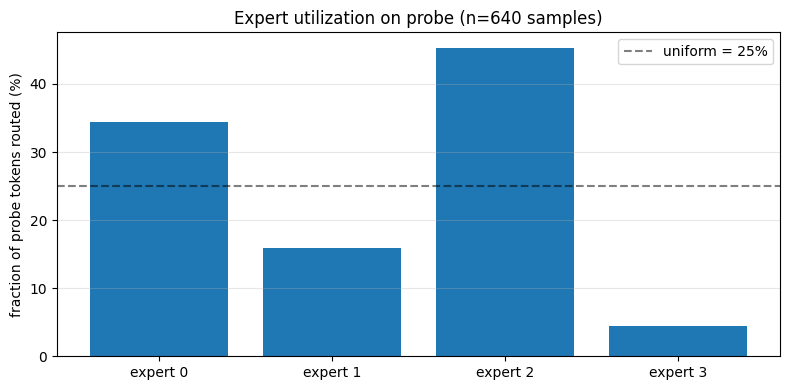

In [11]:
# Run the router forward on the probe and collect per-token top-1 assignments.
# This gives the fraction of tokens routed to each expert.
model.net.eval()
with torch.no_grad():
    flat = probe_X.view(probe_X.size(0), -1).to(model.device)
    router_logits = moe_layer.router(flat)
    top1_expert = router_logits.argmax(dim=1).cpu().numpy()

fractions = [(top1_expert == k).sum() / len(top1_expert) for k in range(NUM_EXPERTS)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(NUM_EXPERTS), [f * 100 for f in fractions], color='tab:blue')
ax.set_xticks(range(NUM_EXPERTS))
ax.set_xticklabels([f"expert {k}" for k in range(NUM_EXPERTS)])
ax.set_ylabel("fraction of probe tokens routed (%)")
ax.set_title(f"Expert utilization on probe (n={len(top1_expert)} samples)")
ax.axhline(100 / NUM_EXPERTS, linestyle='--', color='k', alpha=0.5, label=f"uniform = {100/NUM_EXPERTS:.0f}%")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## 6.3 Discussion

The expected pattern:

- **Aux loss decreases** from initialization to after training — the load-balancing penalty pushes the router away from the collapse to which random initialization is biased.
- **Expert utilization** post-training is closer to uniform (25% per expert) than at init. Perfect uniformity isn't the goal — *useful* specialization can show up as 30/30/20/20-ish, with one expert handling visually-distinctive classes (e.g., bags + boots together) and another specializing on the t-shirt/shirt confusion pair.
- **Train loss** decreases — the supervised signal is the dominant gradient; aux loss is just a regularizer.

The pedagogical headline: **MoE buys you total parameter capacity without proportional per-token FLOPs** — at the cost of a load-balancing penalty that you have to pay attention to. `nnx`'s `MoELinear` + `moe_train_step_factory` makes the recipe drop-in: one layer swap, one factory call, one new metric to watch (`last_aux_loss`).
